In [64]:
import pandas as pd

df = pd.read_csv("/Users/rorihoover/Documents/GitHub/yarn_economics/data_scripts/real/april_final_data.csv")

In [65]:
df = df[~df['year_created'].isin([2007, 2026])]
#get rid of before 2007 and after 2025
df = df[(df['year_started'] >= 2007) & (df['year_started'] <= 2025)]

In [66]:
print(df.columns.tolist())

['Unnamed: 0', 'comments_count', 'completed', 'craft_id', 'created_at', 'favorites_count', 'id', 'made_for', 'made_for_user_id', 'name', 'pattern_id', 'permalink', 'progress', 'project_status_changed', 'project_status_id', 'rating', 'size', 'started', 'updated_at', 'user_id', 'pattern_name', 'craft_name', 'status_name', 'tag_names', 'photos_count', 'gauge', 'row_gauge', 'gauge_repeats', 'gauge_divisor', 'gauge_pattern', 'completed_day_set', 'started_day_set', 'user.id', 'user.username', 'user.profile_country_code', 'made_for_semiprocessed', 'started_dt', 'created_at_dt', 'lag_days', 'year_created', 'month_created', 'year_started', 'month_started']


In [67]:
#bget monthly made for
keep_vals = [
    'self', 'donation', 'bussiness', 'mom', 'gift', 'friend',
    'unknown', 'test', 'daughter', 'fun', 'home', 'sister',
    'niece', 'child', 'husband', 'son', 'dad', 'granddaughter',
    'grandma', 'family', 'nephew', 'coworker'
]
monthly_counts = (
    df.groupby(['month_started', 'made_for_semiprocessed'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
monthly_counts = monthly_counts[['month_started'] + keep_vals]

In [68]:
#sum of comments_count per month 
#sum of photos_count per month 
#sum of favorites_count per month 
monthly_counts2 = (
    df.groupby('month_started').agg(
        comments_per_month=('comments_count', 'sum'),
        photos_per_month=('photos_count', 'sum'),
        favorites_per_month=('favorites_count', 'sum'),
    )
    .reset_index()
)
#get total projects created per month 
#get total projects started per month 
projects_created_per_month = (
    df.groupby('month_started')
    .size()
    .reset_index(name='projects_created_per_month')
)
projects_started_per_month = (
    df[df['started_dt'].notna()]
    .groupby('month_started')
    .size()
    .reset_index(name='projects_started_per_month')
)
#lag binned by month started
monthly_counts3 = (
    df.groupby('month_started').agg(
        lag_days=('lag_days', 'mean')
    )
    .reset_index()
)

In [69]:
# join monthly_counts3, monthly_counts, monthly_counts2,projects_created_per_month, projects_started_per_month

merged_df = pd.merge(monthly_counts2, monthly_counts3, on='month_started')
merged_df = pd.merge(monthly_counts, merged_df, on='month_started')
merged_df = pd.merge(projects_started_per_month, merged_df, on='month_started')
merged_df = pd.merge(projects_created_per_month, merged_df, on='month_started')

In [70]:
#add in economic data
merged_df.head()

,month_started,projects_created_per_month,projects_started_per_month,self,donation,bussiness,mom,gift,friend,unknown,...,dad,granddaughter,grandma,family,nephew,coworker,comments_per_month,photos_per_month,favorites_per_month,lag_days
0,2007-01,1960,1960,373,48,42,36,39,15,35,...,1,9,10,3,5,0,1559,4593,12562,1104.360825
1,2007-02,378,378,85,4,11,6,0,5,1,...,0,1,0,0,0,0,377,764,2222,1026.919540
2,2007-03,346,346,58,0,5,3,2,4,2,...,0,1,0,1,1,0,212,827,1189,1001.028571
3,2007-04,363,363,67,2,7,4,3,2,1,...,0,2,0,1,0,0,329,696,2129,961.377778
4,2007-05,359,359,81,17,7,5,1,5,2,...,0,1,0,0,0,0,336,778,1207,585.247423


In [71]:
merged_df['month_started'] = pd.to_datetime(merged_df['month_started'], format='%Y-%m')

# Extract year and month
merged_df['year'] = merged_df['month_started'].dt.year
merged_df['month'] = merged_df['month_started'].dt.month
merged_df = merged_df.drop(columns="month_started")
merged_df.head()

,projects_created_per_month,projects_started_per_month,self,donation,bussiness,mom,gift,friend,unknown,test,...,grandma,family,nephew,coworker,comments_per_month,photos_per_month,favorites_per_month,lag_days,year,month
0,1960,1960,373,48,42,36,39,15,35,1,...,10,3,5,0,1559,4593,12562,1104.360825,2007,1
1,378,378,85,4,11,6,0,5,1,0,...,0,0,0,0,377,764,2222,1026.919540,2007,2
2,346,346,58,0,5,3,2,4,2,0,...,0,1,1,0,212,827,1189,1001.028571,2007,3
3,363,363,67,2,7,4,3,2,1,8,...,0,1,0,0,329,696,2129,961.377778,2007,4
4,359,359,81,17,7,5,1,5,2,0,...,0,0,0,0,336,778,1207,585.247423,2007,5


In [72]:
cpi = pd.read_csv("/Users/rorihoover/Documents/GitHub/yarn_economics/new_CPI.csv")
unemp= pd.read_csv("/Users/rorihoover/Documents/GitHub/yarn_economics/unemployment_not_seasonaly_adj.csv")
gdp = pd.read_csv("/Users/rorihoover/Documents/GitHub/yarn_economics/GDP.csv")

In [73]:
cpi.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,HALF1,HALF2
0,2000,168.8,169.8,171.2,171.3,171.5,172.4,172.8,172.8,173.7,174,174.1,174.0,170.8,173.6
1,2001,175.1,175.8,176.2,176.9,177.7,178.0,177.5,177.5,178.3,177.7,177.4,176.7,176.6,177.5
2,2002,177.1,177.8,178.8,179.8,179.8,179.9,180.1,180.7,181.0,181.3,181.3,180.9,178.9,180.9
3,2003,181.7,183.1,184.2,183.8,183.5,183.7,183.9,184.6,185.2,185,184.5,184.3,183.3,184.6
4,2004,185.2,186.2,187.4,188.0,189.1,189.7,189.4,189.5,189.9,190.9,191.0,190.3,187.6,190.2


In [74]:
# long format
cpi_long = cpi.melt(id_vars='Year', 

                       value_vars=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
                       var_name='month_str', 
                       value_name='CPI')

# Map month names to numbers
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr':4,'May':5,'Jun':6,
             'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
cpi_long['month'] = cpi_long['month_str'].map(month_map)
cpi_long = cpi_long.drop(columns='month_str')

cpi_long['year']=cpi_long['Year']
cpi_long = cpi_long.drop(columns='Year')
merged_df = pd.merge(cpi_long, merged_df, on=['year','month'])


In [75]:
gdp.head()

,observation_date,GDP
0,2007-01-01,14215.651
1,2007-04-01,14402.082
2,2007-07-01,14564.117
3,2007-10-01,14715.058
4,2008-01-01,14706.538


In [76]:
gdp['observation_date'] = pd.to_datetime(gdp['observation_date'])

gdp['year'] = gdp['observation_date'].dt.year
gdp['month'] = gdp['observation_date'].dt.month
gdp = gdp.drop(columns='observation_date')

merged_df = pd.merge(gdp, merged_df, on=['year','month'])

In [77]:
unemp.head()

,Year,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
0,2000,5212.0,5863.0,5264.0,6284.0,6316,6028.0,5959.0,6069.0,5460.0,5336.0,5153,5359.0
1,2001,6004.0,7017.0,7773.0,6523.0,6647,6858.0,6816.0,6509.0,5901.0,7617.0,7175,6766.0
2,2002,8255.0,8271.0,8209.0,8823.0,9051,8693.0,8758.0,8776.0,7969.0,8170.0,7769,7790.0
3,2003,8501.0,8830.0,7945.0,9260.0,9395,9319.0,9649.0,9018.0,8500.0,8269.0,8169,8436.0
4,2004,7837.0,7940.0,7599.0,8770.0,9144,8518.0,8616.0,8834.0,7792.0,7665.0,7531,7545.0


In [78]:
unemp_long = unemp.melt(id_vars='Year', 

                       value_vars=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
                       var_name='month_str', 
                       value_name='unemp')

# Map month names to numbers
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr':4,'May':5,'Jun':6,
             'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
unemp_long['month'] = unemp_long['month_str'].map(month_map)
unemp_long['year']=unemp_long['Year']
unemp_long = unemp_long.drop(columns='month_str')
unemp_long = unemp_long.drop(columns='Year')
merged_df = pd.merge(unemp_long, merged_df, on=['year','month'])

In [79]:
merged_df.head()

,unemp,month,year,GDP,CPI,projects_created_per_month,projects_started_per_month,self,donation,bussiness,...,dad,granddaughter,grandma,family,nephew,coworker,comments_per_month,photos_per_month,favorites_per_month,lag_days
0,7649,1,2007,14215.651,202.416,1960,1960,373,48,42,...,1,9,10,3,5,0,1559,4593,12562,1104.360825
1,8221,1,2008,14706.538,211.08,5655,5655,1169,71,94,...,13,1,12,16,8,6,5190,13382,31615,214.320057
2,13009,1,2009,14430.902,211.143,8016,8016,1608,130,187,...,4,4,7,13,10,5,6040,18274,42575,38.342941
3,16147,1,2010,14764.610,216.687,9632,9632,1724,164,208,...,11,13,15,10,18,8,8110,24458,49733,38.123365
4,14937,1,2011,15351.448,220.223,11746,11746,1707,193,211,...,7,13,11,4,20,11,8766,29060,46008,23.687669


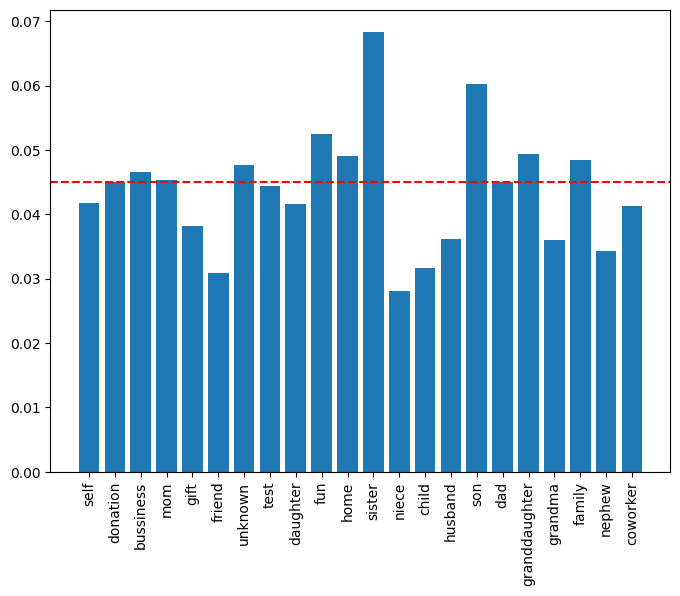

In [113]:
import numpy as np 

# graph variance of each category overtime ???????

# get np.var() for each column in keep_vals
def ss(arr):
    mi, ma = min(arr), max(arr)
    npa = np.array(arr)
    ou = (npa - mi) / (ma - mi)
    return ou

vardict = {}
for tag in keep_vals:
    vardict[tag] = np.var(ss(np.array(merged_df[tag])))
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.bar(x = list(vardict.keys()), height = vardict.values())
plt.axhline(y=0.045, c = 'r', linestyle='--')

plt.xticks(rotation=90)
plt.show()

#want high variance 

In [107]:
tmpdf = pd.DataFrame(vardict, index = [0]).T.sort_values(0)
tmpdf

,0
niece,0.028155
friend,0.030948
child,0.031636
nephew,0.034233
grandma,0.035984
husband,0.036207
gift,0.038220
coworker,0.041214
daughter,0.041629
self,0.041704


In [ ]:
delete_vals =  [
 'niece',
'friend',
'child',
'nephew',
'grandma',
'husband',
'gift',
'coworker',
'daughter',
'self',
'test','dad' 
]

merged_df =merged_df.drop(columns=delete_vals)
merged_df.drop(merged_df.tail(1).index,inplace=True)

In [119]:
merged_df.to_csv('final.csv')

In [124]:
cols = list(merged_df.columns)
outcomes = ['unemp', 'GDP', 'CPI']
time = ['month', 'year']
regress = [v for v in cols if v not in outcomes]
regress = [v for v in regress if v not in time]
outcomes, regress, time

(['unemp', 'GDP', 'CPI'],
 ['projects_created_per_month',
  'projects_started_per_month',
  'donation',
  'bussiness',
  'mom',
  'unknown',
  'fun',
  'home',
  'sister',
  'son',
  'granddaughter',
  'family',
  'comments_per_month',
  'photos_per_month',
  'favorites_per_month',
  'lag_days'],
 ['month', 'year'])

In [143]:
X = np.array(merged_df[regress].apply(ss))
t = np.array(merged_df[time])
y = np.array(merged_df[outcomes]).astype(float)

In [147]:
merged_df[regress].apply(ss)

,projects_created_per_month,projects_started_per_month,donation,bussiness,mom,unknown,fun,home,sister,son,granddaughter,family,comments_per_month,photos_per_month,favorites_per_month,lag_days
0,0.119438,0.119438,0.141975,0.179612,0.192771,0.263566,0.104651,0.092308,0.139535,0.113636,0.264706,0.100000,0.152815,0.087587,0.173914,1.000000
1,0.395782,0.395782,0.212963,0.432039,0.451807,0.410853,0.627907,0.615385,0.418605,0.431818,0.029412,0.533333,0.579640,0.285124,0.471525,0.193308
2,0.572358,0.572358,0.395062,0.883495,0.759036,0.697674,0.720930,0.323077,0.813953,0.386364,0.117647,0.433333,0.679558,0.395073,0.642721,0.033810
3,0.693217,0.693217,0.500000,0.985437,1.000000,0.775194,0.755814,0.692308,0.465116,1.000000,0.382353,0.333333,0.922887,0.534062,0.754530,0.033611
4,0.851320,0.851320,0.589506,1.000000,0.710843,1.000000,0.906977,1.000000,0.883721,0.477273,0.382353,0.133333,1.000000,0.637494,0.696345,0.020527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,0.589260,0.589260,0.780864,0.543689,0.439759,0.054264,0.151163,0.569231,0.302326,0.136364,0.529412,0.133333,0.114494,0.639741,0.300031,0.016586
71,0.520604,0.520604,0.324074,0.703883,0.331325,0.193798,0.116279,0.323077,0.139535,0.136364,0.264706,0.766667,0.060538,0.562853,0.220900,0.020217
72,0.566824,0.566824,0.712963,0.674757,0.343373,0.178295,0.302326,0.092308,0.604651,0.068182,0.029412,0.366667,0.060538,0.581709,0.213777,0.015409
73,0.625682,0.625682,0.527778,0.276699,0.560241,0.224806,0.104651,0.123077,0.279070,0.113636,0.294118,0.266667,0.131421,0.635943,0.542752,0.009801


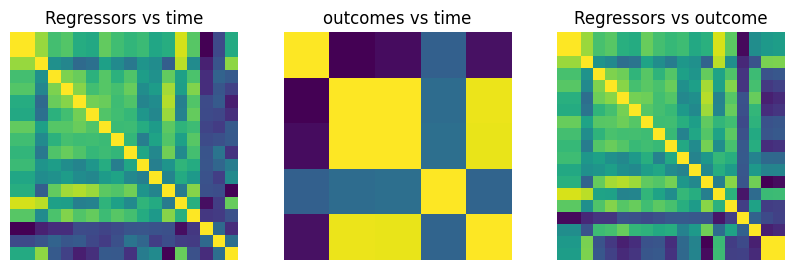

In [148]:
# next steps: 3 covariance matrix heatmaps
X_t = np.corrcoef(X.T, t.T)
y_t = np.corrcoef(y.T, t.T)
X_y = np.corrcoef(X.T, y.T)

fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].imshow(X_t)
axes[0].axis('off')
axes[0].set_title('Regressors vs time')
axes[1].imshow(y_t)
axes[1].axis('off')
axes[1].set_title('outcomes vs time')
axes[2].imshow(X_y)
axes[2].axis('off')
axes[2].set_title('Regressors vs outcome')
plt.show()

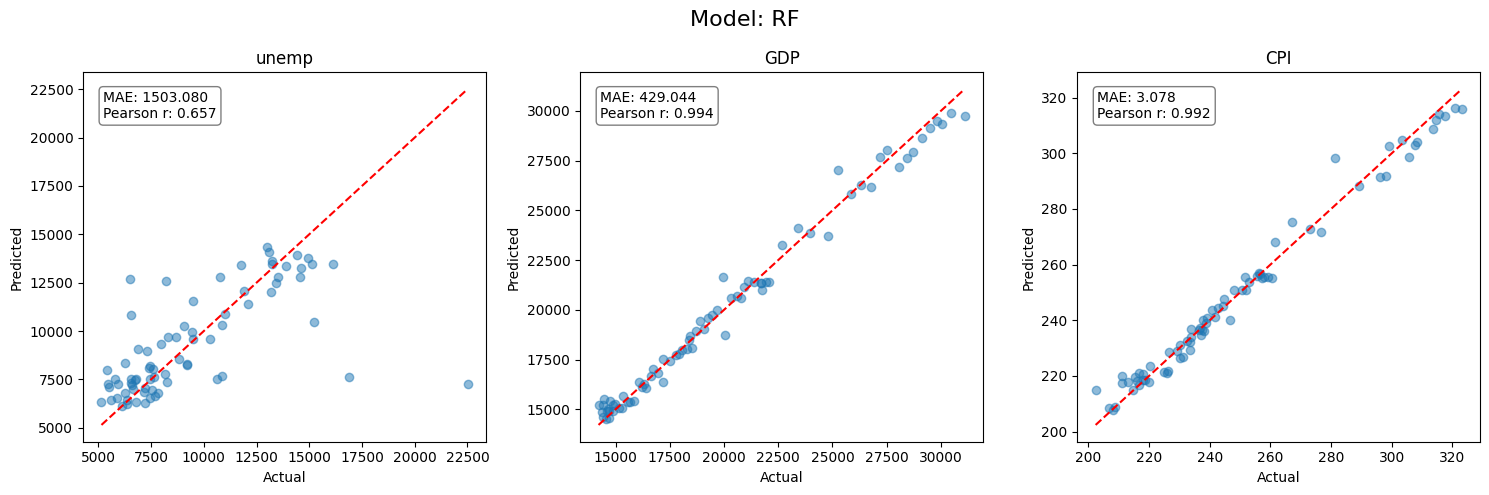

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

def visualize_kfold(X, y, ylab, model_type='ridge', n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    models = {
        'ridge': Ridge(alpha=1.0),
        'lasso': Lasso(alpha=0.1),
        'rf': RandomForestRegressor(n_estimators=100, random_state=42)
    }
    model = models.get(model_type, Ridge())
    y_preds = np.zeros_like(y)

    for train_ix, test_ix in kf.split(X):
        model.fit(X[train_ix], y[train_ix])
        y_preds[test_ix] = model.predict(X[test_ix])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Model: {model_type.upper()}', fontsize=16)
    for i in range(3):
        y_true = y[:, i]
        y_pred = y_preds[:, i]
        
        mae = mean_absolute_error(y_true, y_pred)
        r_coeff, _ = pearsonr(y_true, y_pred)
        
        axes[i].scatter(y_true, y_pred, alpha=0.5)
        
        mn, mx = y_true.min(), y_true.max()
        axes[i].plot([mn, mx], [mn, mx], 'r--')
        
        stats_text = f'MAE: {mae:.3f}\nPearson r: {r_coeff:.3f}'
        axes[i].text(0.05, 0.95, stats_text, transform=axes[i].transAxes, 
                     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
        
        axes[i].set_title(f'{ylab[i]}')
        axes[i].set_xlabel('Actual')
        axes[i].set_ylabel('Predicted')
    
    plt.tight_layout()
    plt.show()

X_combined = np.hstack([X, t])
visualize_kfold(X_combined, y, outcomes, 'rf', n_splits=20)